# 03. Baseline Model: Balanced Logistic Regression
**Author**: Yordanos Andargachew (Phone: `+251 952 190 305`)  
**Project**: Bank Loan Risk Prediction System  

---

## 1. Model Formulation & Baseline Role
Logistic Regression serves as the canonical linear baseline in credit scoring. It models the log-odds of loan default:
$$\ln\left(\frac{P(Y=1|X)}{1 - P(Y=1|X)}\right) = \beta_0 + \sum_{j=1}^p \beta_j X_j$$

To handle the 70/30 class imbalance, we employ `class_weight='balanced'`, which inversely weights samples proportionally to class frequencies:
$$w_k = \frac{n}{2 \times n_k}$$

In [1]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("."))

from src.preprocessor import CreditDataPreprocessor

# Load dataset
data_path = os.path.join("..", "data", "dataset.csv")
if not os.path.exists(data_path):
    data_path = os.path.join("data", "dataset.csv")

df = pd.read_csv(data_path)
X = df.drop(columns=['Risk'])
y = CreditDataPreprocessor.encode_target(df['Risk'])

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Load preprocessor
models_dir = os.path.join("..", "models")
if not os.path.exists(models_dir):
    models_dir = "models"

preprocessor = CreditDataPreprocessor.load(os.path.join(models_dir, "preprocessor.pkl"))
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print(f"X_train_trans shape: {X_train_trans.shape}")
print(f"X_test_trans shape:  {X_test_trans.shape}")

X_train_trans shape: (800, 26)
X_test_trans shape:  (200, 26)


## 2. Baseline Model Training

In [2]:
# Initialize Balanced Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs',
    C=1.0
)

# Fit on training data
lr_model.fit(X_train_trans, y_train)
print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


## 3. Evaluation on 20% Holdout Test Split

In [3]:
y_pred = lr_model.predict(X_test_trans)
y_proba = lr_model.predict_proba(X_test_trans)[:, 1]

# Compute metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Logistic Regression Test Metrics ===")
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f} ({prec*100:.2f}%)")
print(f"Recall:    {rec:.4f} ({rec*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Good Risk (0)', 'Bad Risk (1)']))

=== Logistic Regression Test Metrics ===
Accuracy:  0.7150 (71.50%)
Precision: 0.5172 (51.72%)
Recall:    0.7500 (75.00%)
F1-Score:  0.6122
ROC-AUC:   0.7615

Classification Report:
               precision    recall  f1-score   support

Good Risk (0)       0.87      0.70      0.77       140
 Bad Risk (1)       0.52      0.75      0.61        60

     accuracy                           0.71       200
    macro avg       0.69      0.72      0.69       200
 weighted avg       0.76      0.71      0.73       200



## 4. Confusion Matrix & ROC Curve

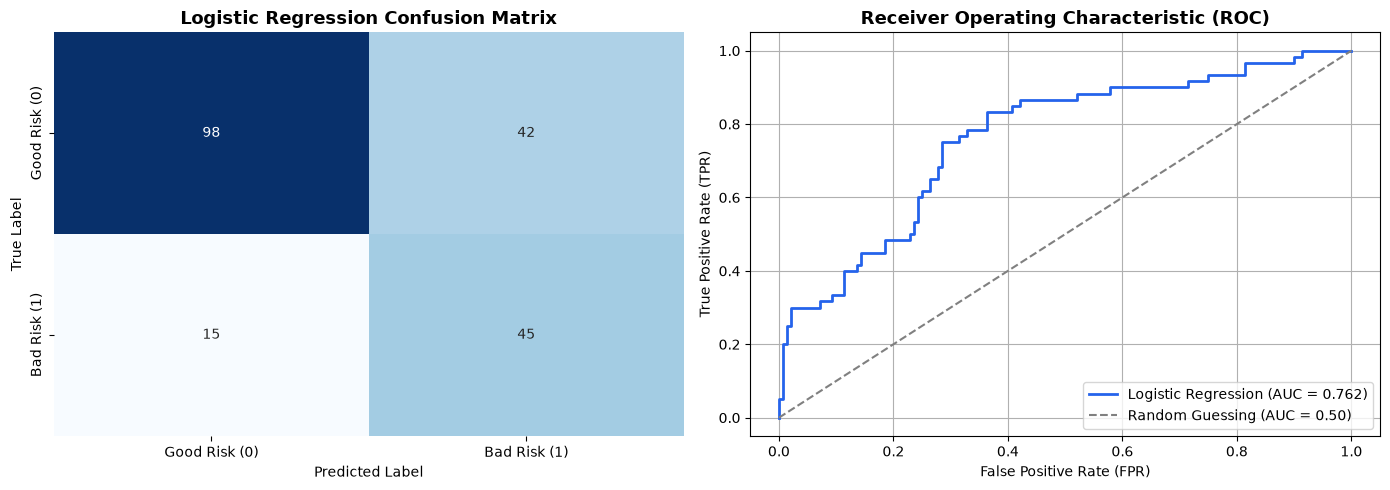

In [4]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Good Risk (0)', 'Bad Risk (1)'],
            yticklabels=['Good Risk (0)', 'Bad Risk (1)'], cbar=False)
axes[0].set_title("Logistic Regression Confusion Matrix", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2563eb', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing (AUC = 0.50)')
axes[1].set_title("Receiver Operating Characteristic (ROC)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("False Positive Rate (FPR)")
axes[1].set_ylabel("True Positive Rate (TPR)")
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Model Interpretability: Learned Coefficients

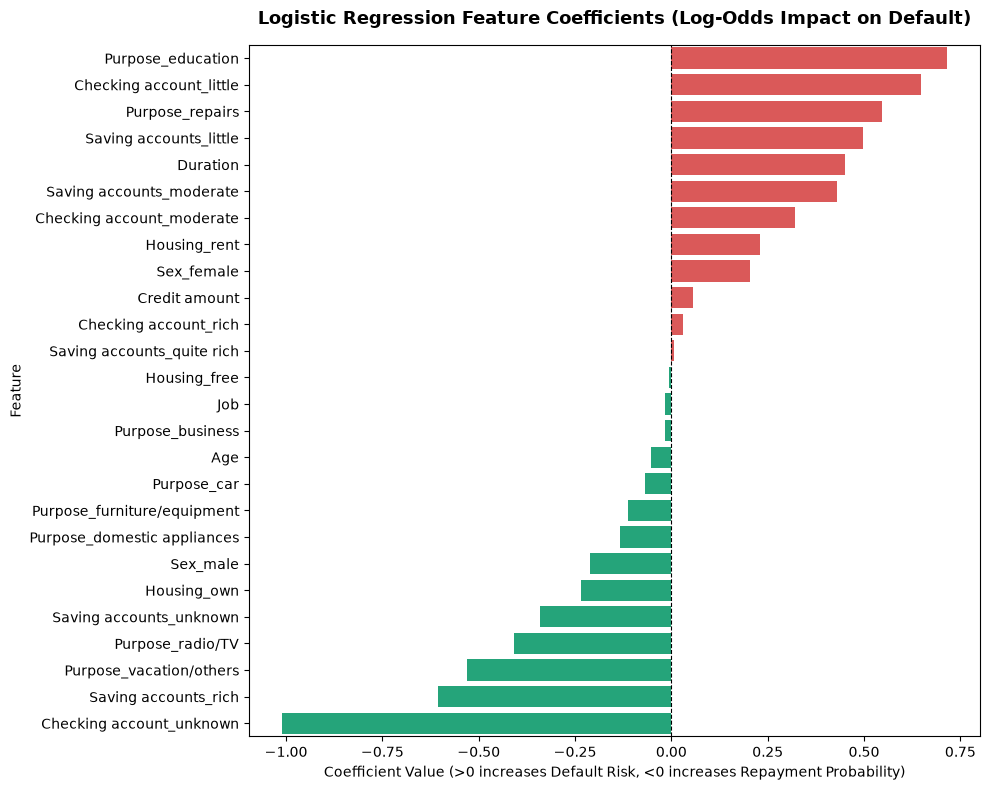

In [5]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#ef4444' if c > 0 else '#10b981' for c in coef_df['Coefficient']]
sns.barplot(data=coef_df, x='Coefficient', y='Feature', hue='Feature', palette=colors, legend=False)
plt.title("Logistic Regression Feature Coefficients (Log-Odds Impact on Default)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Coefficient Value (>0 increases Default Risk, <0 increases Repayment Probability)")
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## 6. Saving Model Artifact

In [6]:
lr_artifact_path = os.path.join(models_dir, "logistic_regression.pkl")
joblib.dump(lr_model, lr_artifact_path)
print(f"Successfully saved Logistic Regression model to '{lr_artifact_path}'!")

Successfully saved Logistic Regression model to '../models/logistic_regression.pkl'!
